<h2>Shor's Algorithm</h2>
We will begin our study of Shor's algorithm this week. It was first proposed by Peter Shor (a computer scientist/mathematician) at MIT in 1997 and represents a milestone in quantum computing. The algorithm can factor a semi-prime  𝑛=𝑝𝑞 (product of two prime numbers  𝑝,𝑞
 ) in time  𝑂(log(𝑛)<sup>3</sup>)   which is polynomial in the size of  𝑛 but on a quantum computer.

 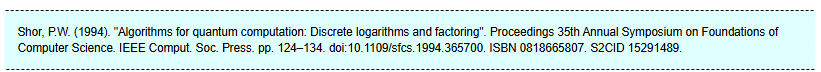
 
 The algorithm is based on some number theory that we will explain in these notes. We will see how the number theory leads to the quantum circuit.

 <h3>Factoring and Order Finding</h3>
 We are given a number  𝑛=𝑝𝑞 and seek to find one of its prime factors  𝑝. Doing so, will help us break the RSA public key cryptosystem. During week # 1 we noted that it was a hard problem for classical computers. The best known classical algorithms have running time  𝑂(𝑘<sup>𝗉𝗈𝗅𝗒(log(𝑘)</sup>)) for a  𝑘 bit number, wherein  𝗉𝗈𝗅𝗒(𝑓(𝑘)) represents a polynomial of fixed degree involving  𝑓(𝑘). For instance,  𝑂(𝑓(𝑘)<sup>3</sup>) complexity would be an example of  𝗉𝗈𝗅𝗒(𝑓(𝑘)). Overall, this represents a super polynomial running time in the size of the number. Currrently, factoring a 2048 bit semi prime is estimated to be impractical (too much time and memory) even using the best known classical computer.

However, the quantum algorithm we present now will solve the problem in time  𝗉𝗈𝗅𝗒(log(𝑘)).

To factor a number  𝑛, we will proceed as follows:
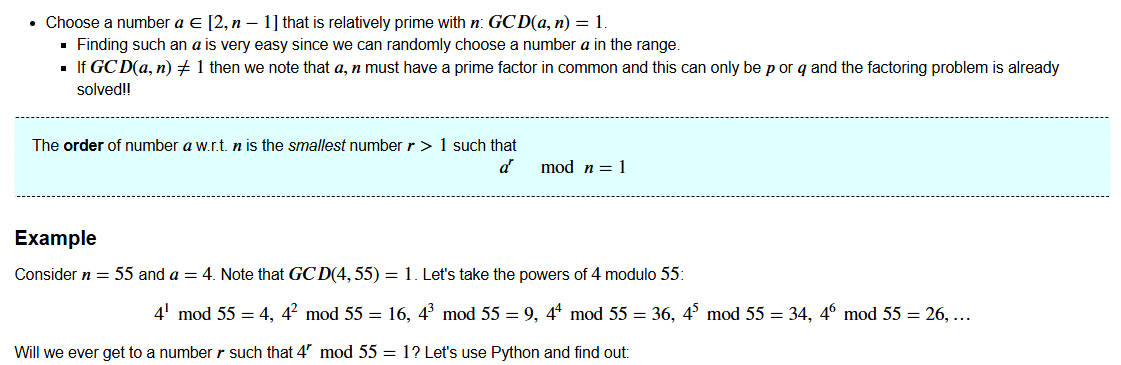



In [1]:
i = 1
m = 4
print(f"{i}, {m}")
while m != 1:
    i = i + 1
    m = (m * 4) % 55
    print(f"{i}, {m}")

1, 4
2, 16
3, 9
4, 36
5, 34
6, 26
7, 49
8, 31
9, 14
10, 1


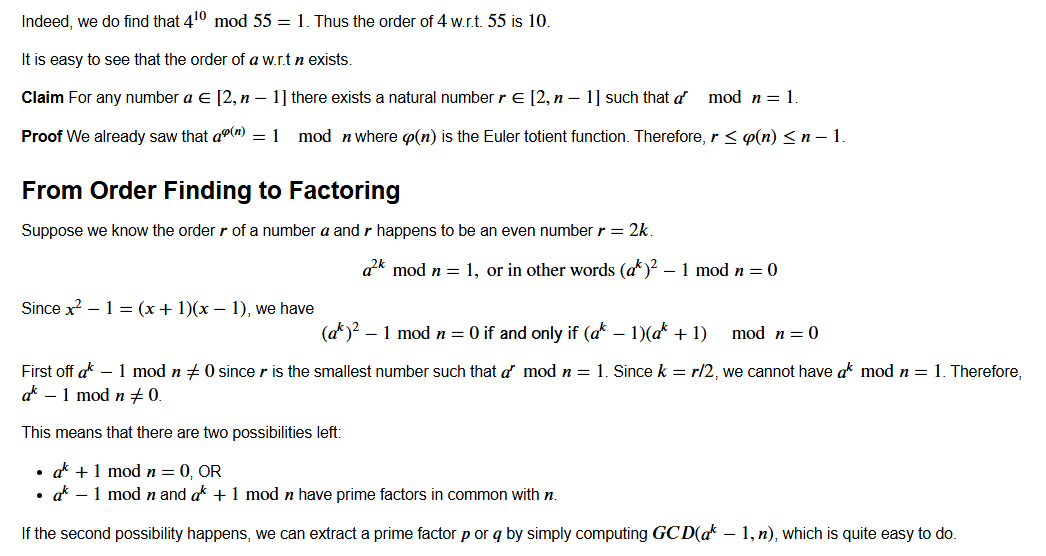

note - 
(a power k -1) mod n = 0 => ((a power k) mod N) - 1 mod n =0
{since modulus can be taken inside  with addition - (a + b) mod m is the same as (a mod m) + (b mod m) mod m }
=> ((a power k) mod N) = 1 which is contradicting since we assume r is smallest number such that (a power r) mod k =1 and k = r/2

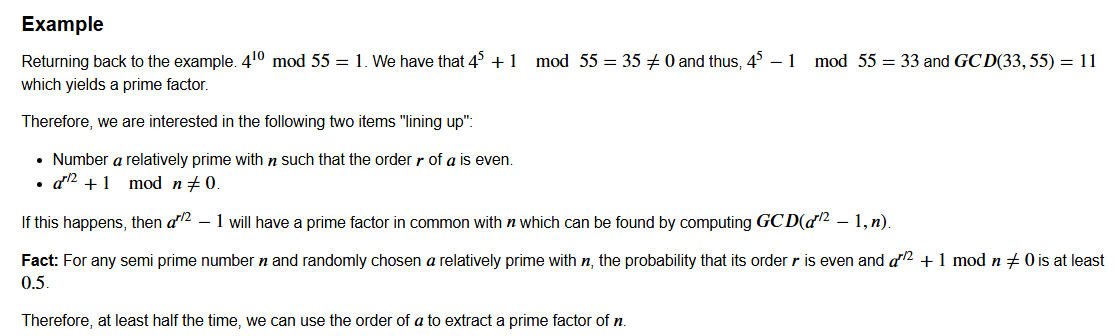

In [2]:
def gcd(m, n):
    if m < n:
        (m,n) = (n,m)
    assert m > 0
    assert n >= 0
    while n != 0:
        (m, n) = (n, m%n)
    return m

def modular_exponentiate(a, k, n): # a^k \mod n
    r = a
    m = 1
    while k != 0:
        if k%2 == 1:
            m = (m * r)%n
        k = k // 2
        r = (r * r) % n
    return m

def find_order(a, n):
    r = 1
    x = a
    while x != 1:
        x = (x * a) % n
        r = r + 1
    return r

def factor_using_order_finding(a, n):
    r = find_order(a, n)
    print(f'Order of {a} w.r.t {n} = {r}')
    if r %2 == 0:
        m = modular_exponentiate(a, r//2, n)
        return gcd(m-1, n)
    print('Bad luck: odd order')
    return 1

In [5]:
f = factor_using_order_finding(2, 55)
print(f'Found factor= {f}')

f = factor_using_order_finding(6, 55)
print(f'Found factor= {f}')

f = factor_using_order_finding(16, 55)
print(f'Found factor= {f}')

n = 3589
a = 75
f = factor_using_order_finding(a, n)
print(f'Found factor= {f}')

n = 758717
a = 5
f = factor_using_order_finding(a, n)
print(f'Found factor= {f}')

n = 758717
a = 1998
f = factor_using_order_finding(a, n)
print(f'Found factor= {f}')


Order of 2 w.r.t 55 = 20
Found factor= 11
Order of 6 w.r.t 55 = 10
Found factor= 5
Order of 16 w.r.t 55 = 5
Bad luck: odd order
Found factor= 1
Order of 75 w.r.t 3589 = 4
Found factor= 37
Order of 5 w.r.t 758717 = 6308
Found factor= 761
Order of 1998 w.r.t 758717 = 63080
Found factor= 997


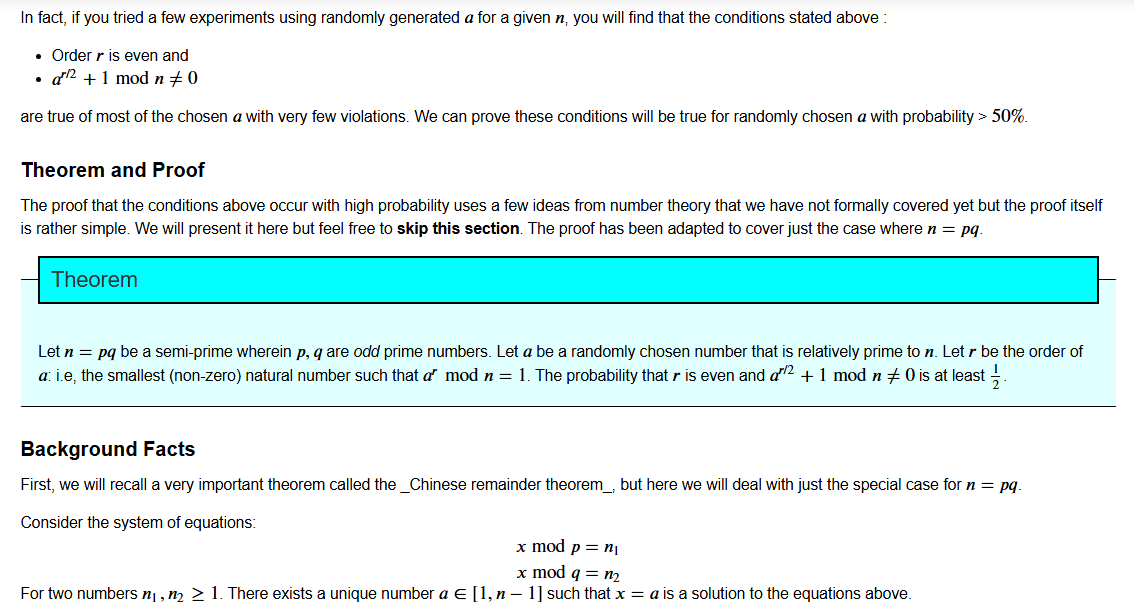
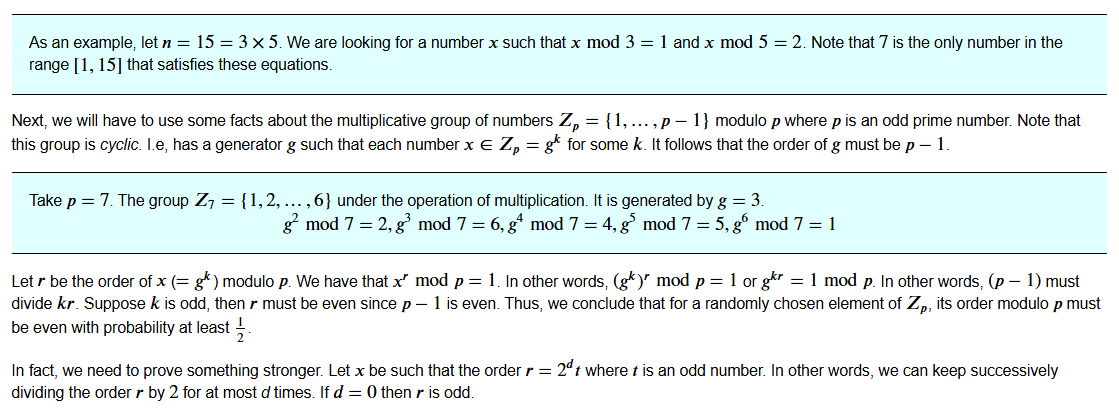
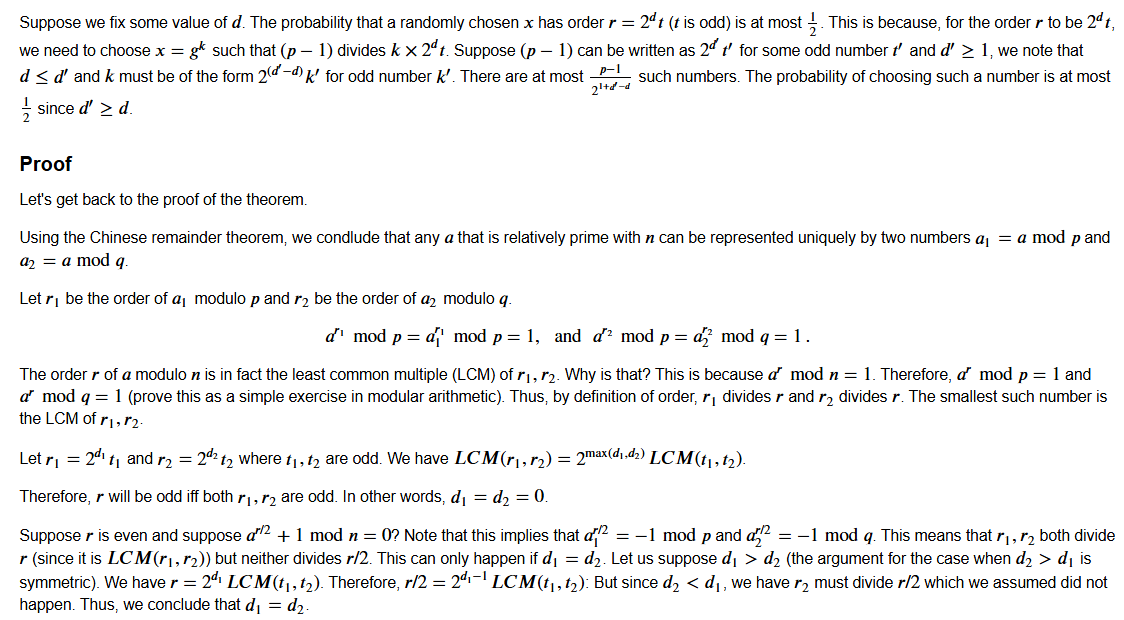
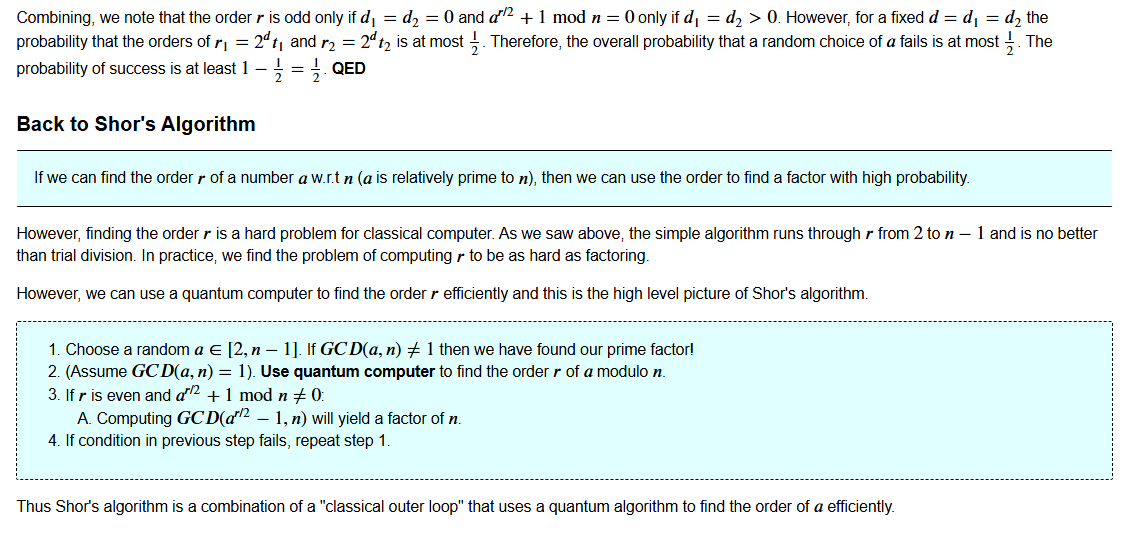


<h2>Order finding on a Quantum Computer </h2>

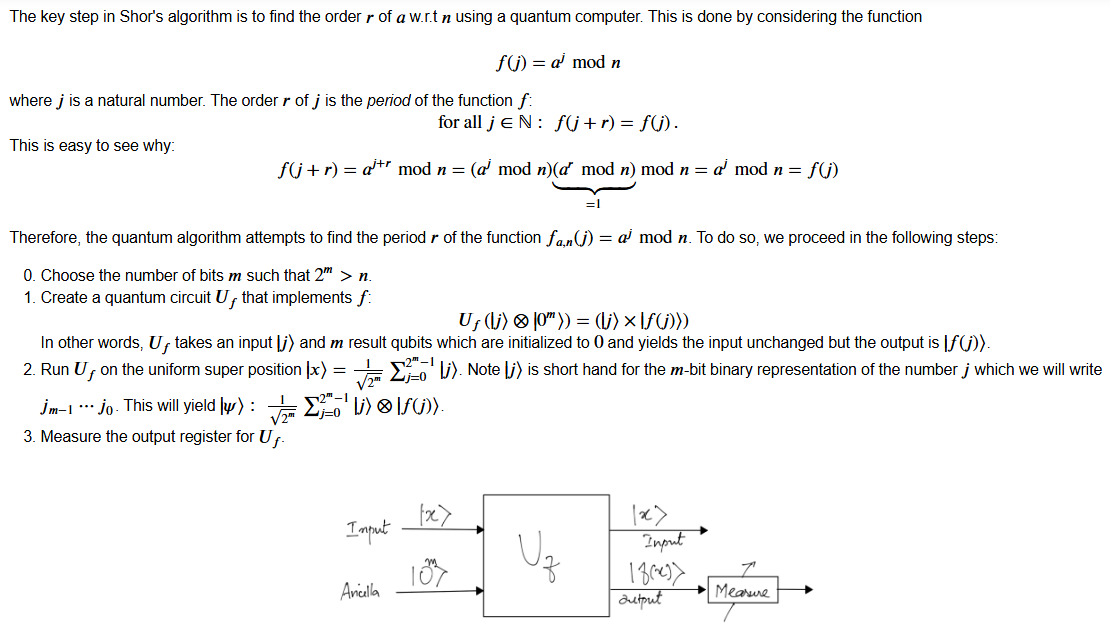

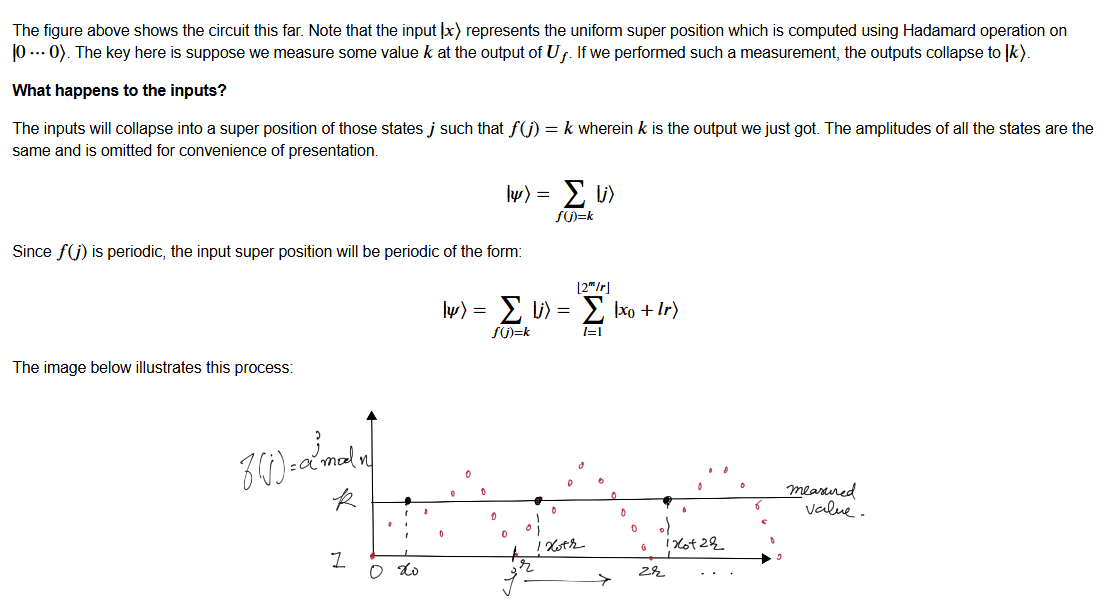

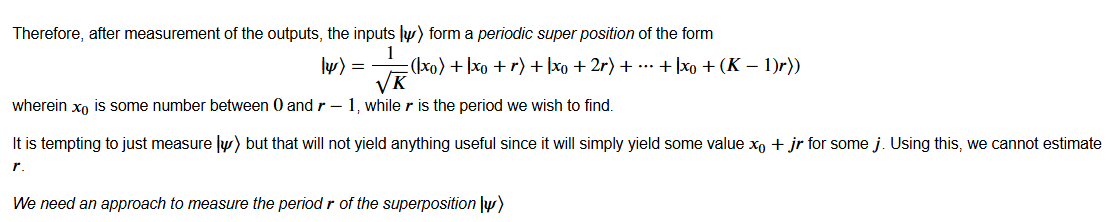

<h2>Quantum Fourier Transform</h2>

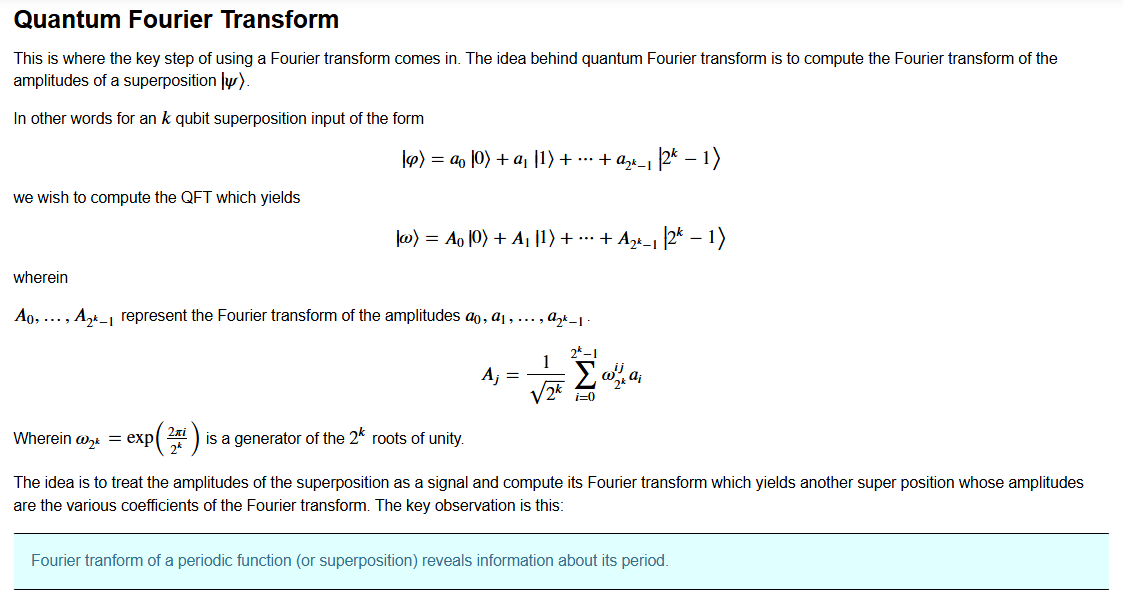


<h2>Illustration of Fourier Transform</h2>

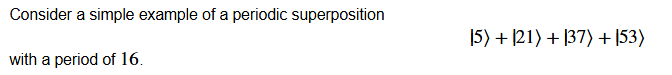

<StemContainer object of 3 artists>

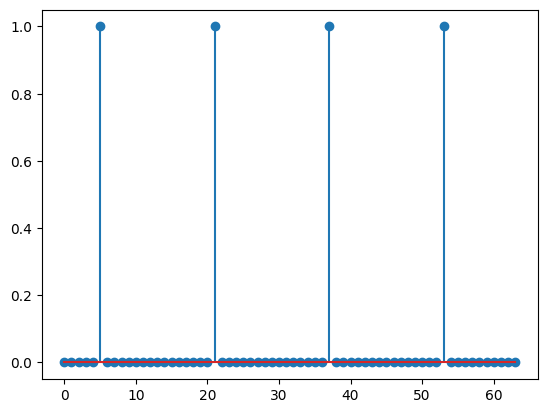

In [6]:
from numpy.fft import fft
from matplotlib import pyplot as plt
values= [5, 21,37, 53]
initial_super_position = [1 if j in values else 0 for j in range(64)]
plt.stem(initial_super_position)

<StemContainer object of 3 artists>

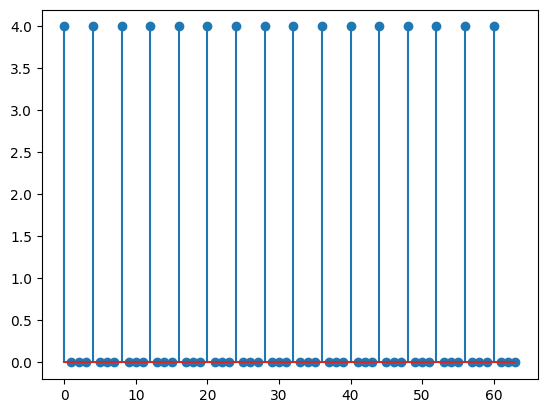

In [7]:
fft_values = fft(initial_super_position, 64)
plt.stem([abs(x) for x in fft_values])

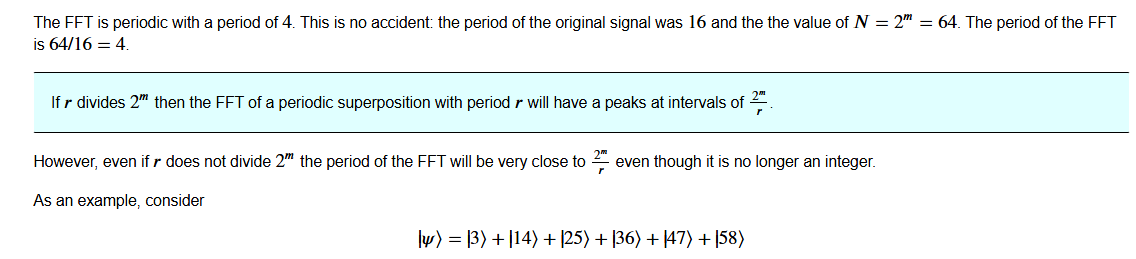

<StemContainer object of 3 artists>

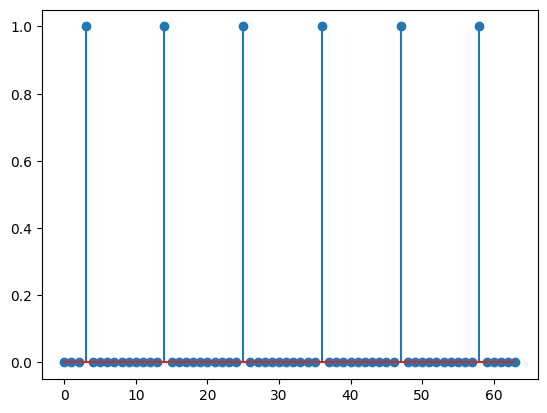

In [8]:
from numpy.fft import fft
from matplotlib import pyplot as plt
values= [3, 14, 25, 36, 47, 58]
initial_super_position = [1 if j in values else 0 for j in range(64)]
plt.stem(initial_super_position)

<StemContainer object of 3 artists>

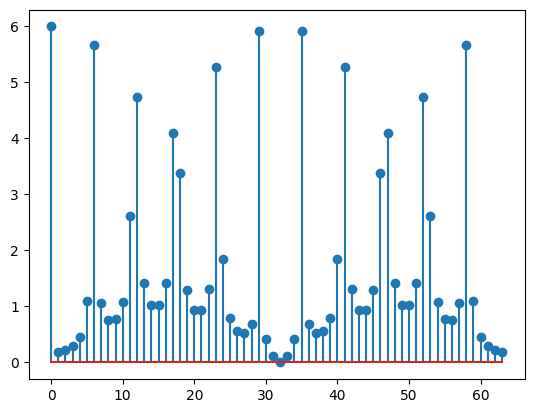

In [9]:
fft_values = fft(initial_super_position, 64)
plt.stem([abs(x) for x in fft_values])

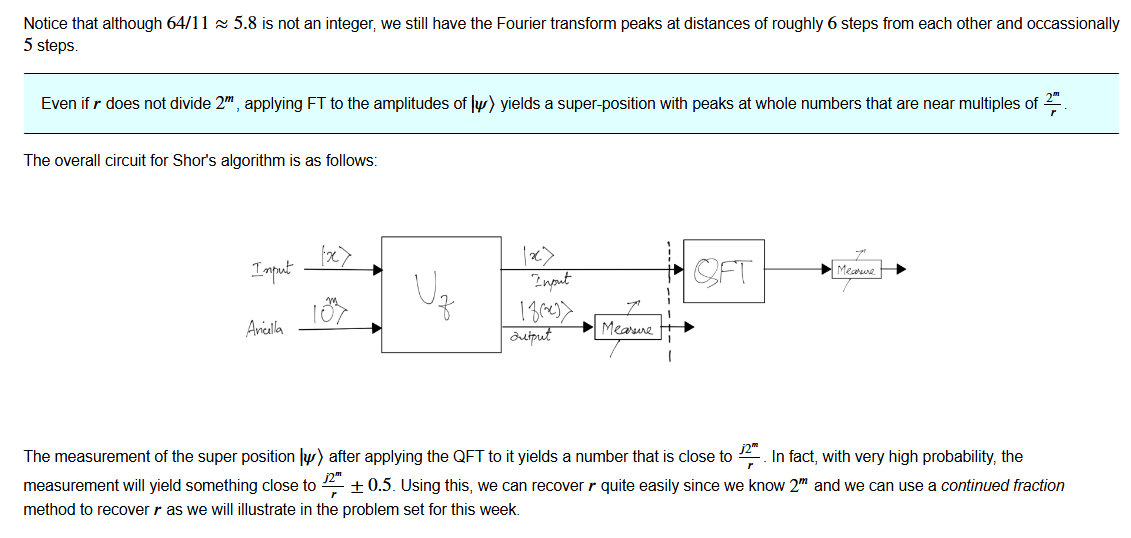

<h2>High-Level Summary of Shor's Algorithm</h2>

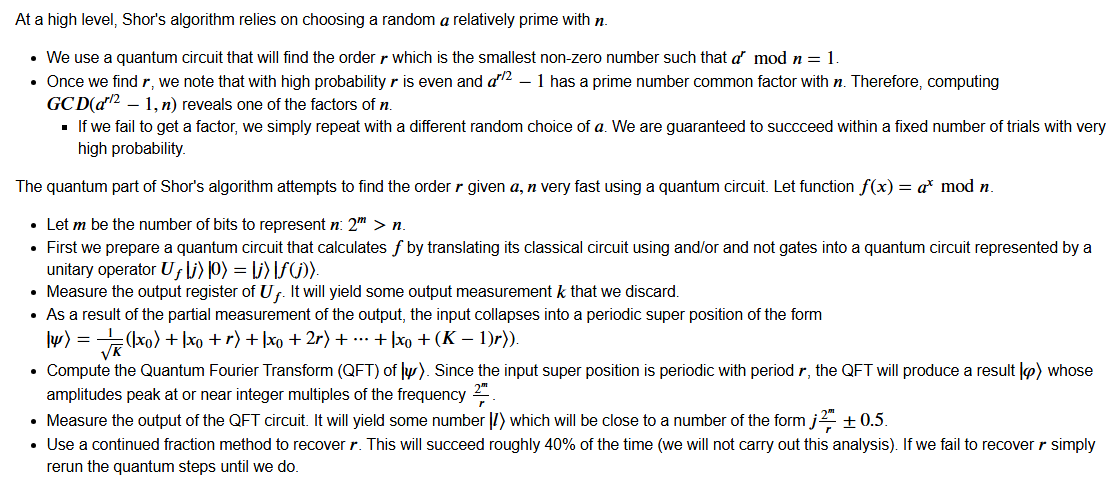


<h2>Quantum Circuit for U<sub>f</sub></h2>

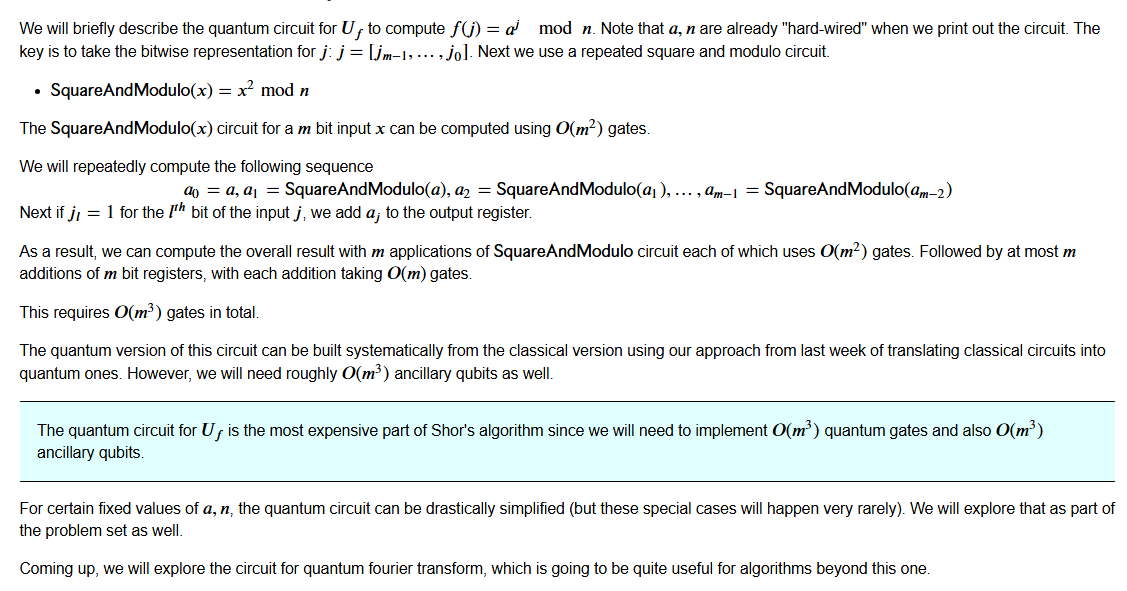
